In [3]:
# Cell 1: Install and Import Dependencies
import mne
import matplotlib.pyplot as plt
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery



In [5]:
# Cell 2: Load a Subject's Data
# We'll use Subject 1 from the BCI Competition IV 2a dataset
dataset = BNCI2014_001()
subject_id = 1
dataset.download(subject_list=[subject_id])
sessions = dataset.get_data(subjects=[subject_id])

# Extract the first run of the first session
# Data is returned as a dictionary: {subject: {session: {run: raw_mne_object}}}
raw = sessions[subject_id]['0train']['0']
raw.load_data()

print(f"Loaded data for Subject {subject_id}")
print(f"Channels: {raw.ch_names}")
print(f"Sampling Rate: {raw.info['sfreq']} Hz")




This is nemar-py 0.3.0.
Preparing to download nm000139 from https://data.nemar.org/
Retrieving 5 of 769 manifest files (16 concurrent downloads).
primary backend failed; falling back to next layer: 'README.md' is not annexed (no sha256/md5 checksum on the manifest entry); the S3 backend has nothing to fetch.


Overall:  43%|████▎     | 5.40k/12.6k [00:00<00:00, 21.1kB/s]


Finished downloading nm000139 v1.0.2.
This is nemar-py 0.3.0.
Preparing to download nm000139 from https://data.nemar.org/
Retrieving 6 of 769 manifest files (16 concurrent downloads).


S3: 100%|██████████| 82.6M/82.6M [00:22<00:00, 3.89MB/s]


Finished downloading nm000139 v1.0.2.
Loaded data for Subject 1
Channels: ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz', 'EOG1', 'EOG2', 'EOG3', 'STI']
Sampling Rate: 250.0 Hz


Using matplotlib as 2D backend.


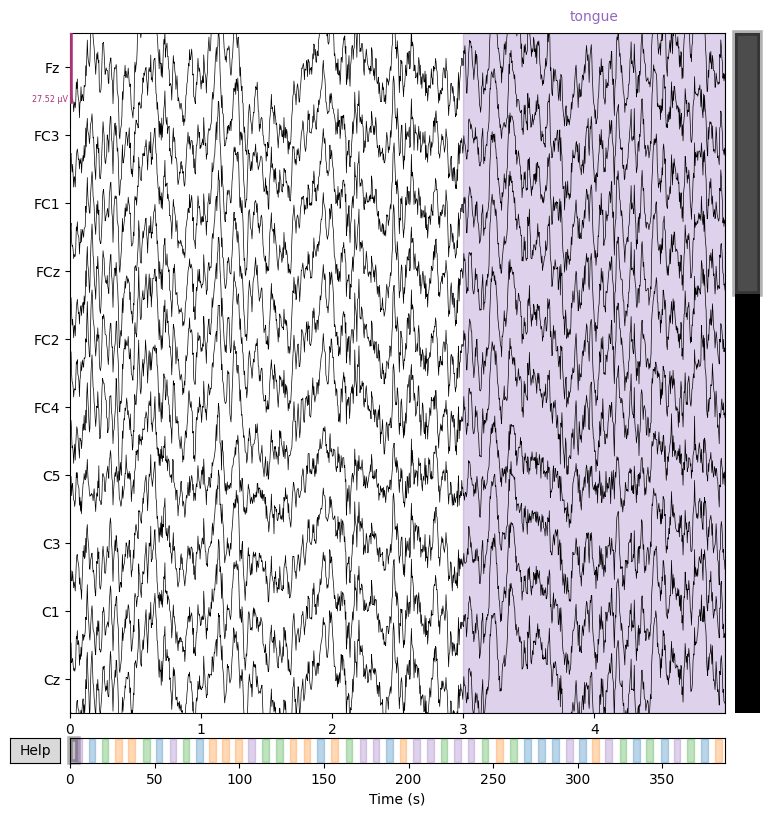

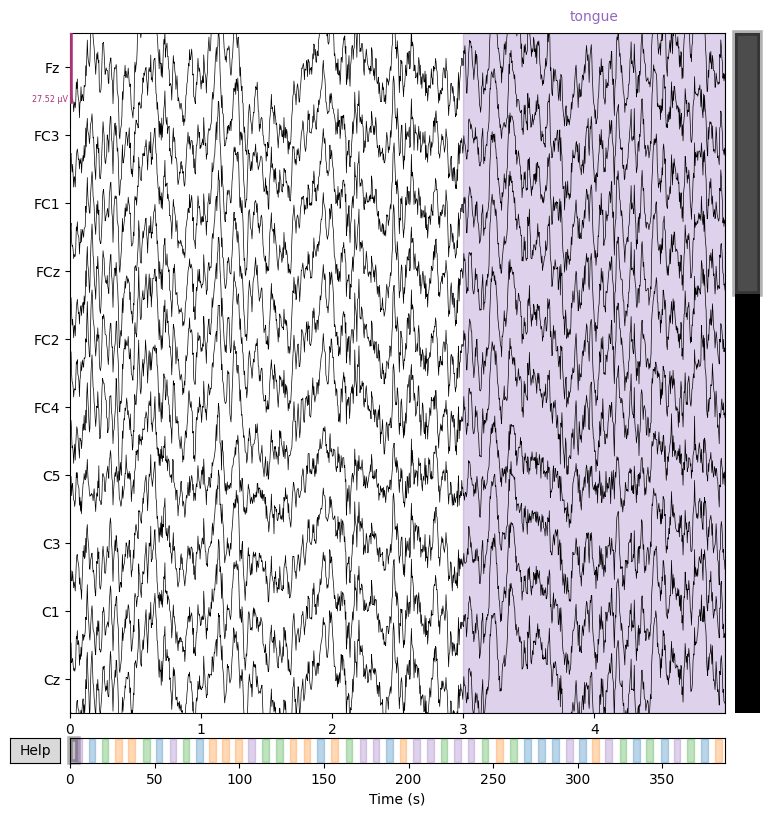

In [6]:
# Cell 3: Visualize Raw Brain Waves
# This will open an interactive plot. Look for rhythmic oscillations.
# If you see huge spikes, those are likely eye blinks or muscle movements.
raw.plot(duration=5, n_channels=10, scalings='auto', title="Raw EEG Signal")


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


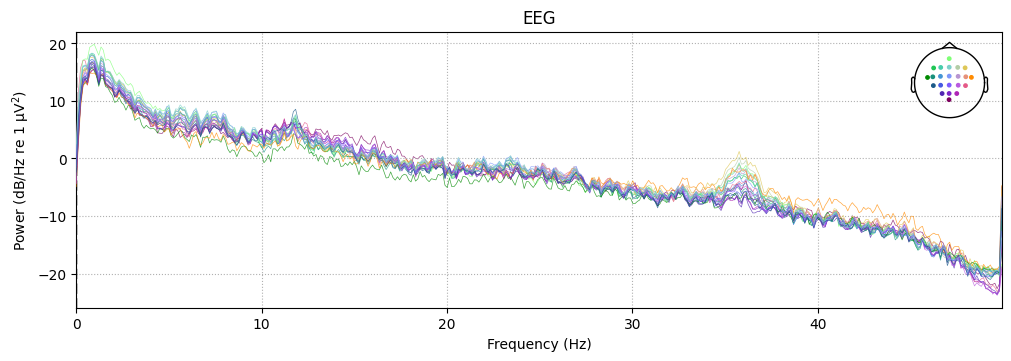

In [7]:


# Cell 4: Power Spectral Density (PSD)
# This shows the "energy" at each frequency. 
# You should see a peak around 10Hz (Alpha/Mu rhythm).
raw.compute_psd(fmax=50).plot()
plt.show()



Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)



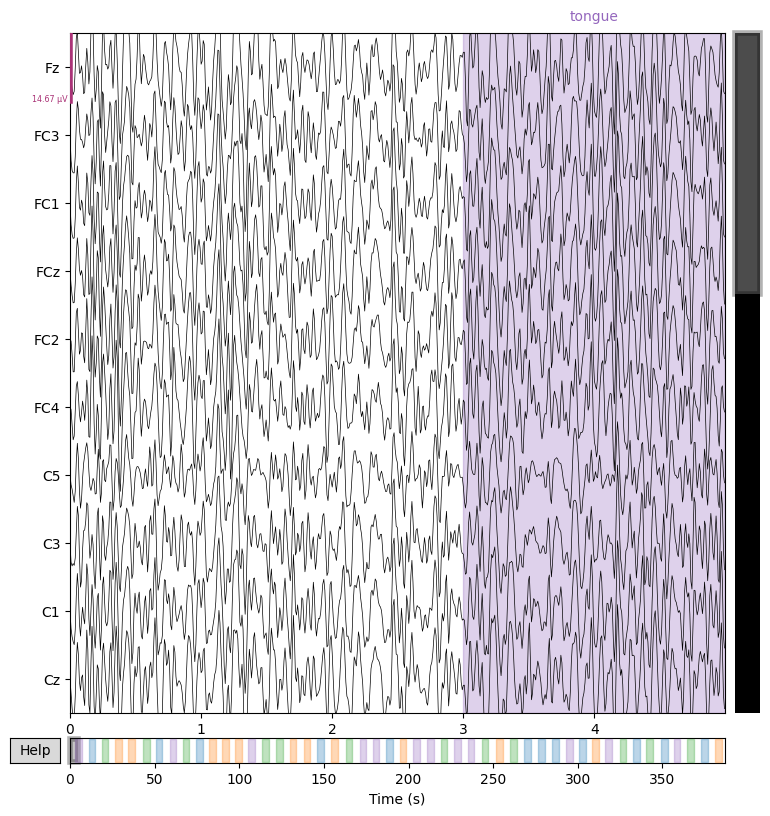

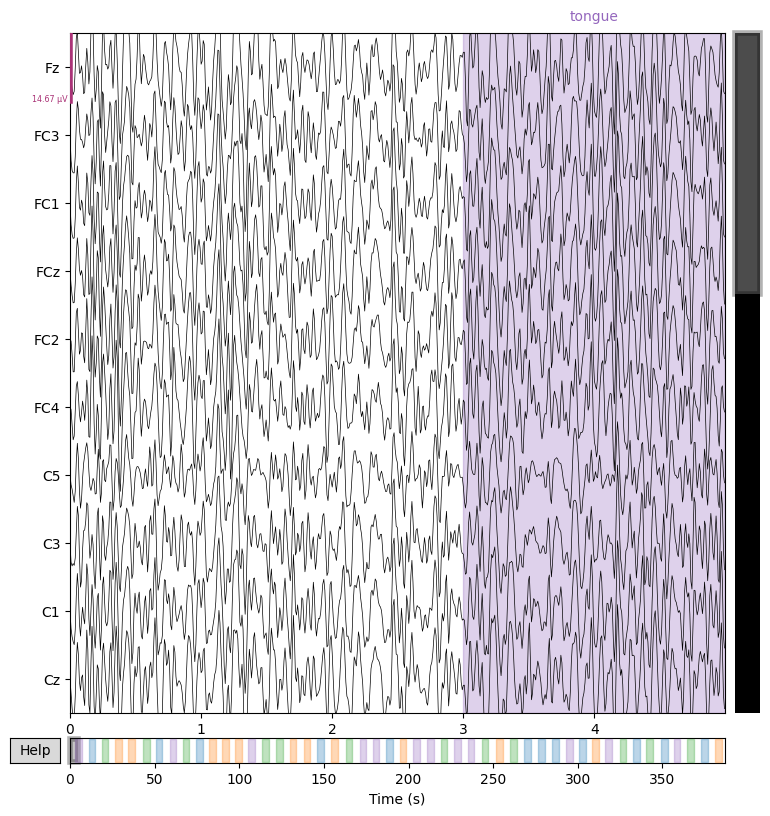

In [8]:
# Cell 5: Basic Preprocessing (Filtering)
# Remove the DC offset (low freq) and electrical line noise (60Hz or 50Hz)
# We focus on 7-30Hz where motor imagery signals are strongest.
raw_filtered = raw.copy().filter(l_freq=7., h_freq=30., fir_design='firwin')

# Compare the filtered signal to the raw signal
raw_filtered.plot(duration=5, n_channels=10, scalings='auto', title="Filtered EEG (7-30Hz)")



Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 1.1s.


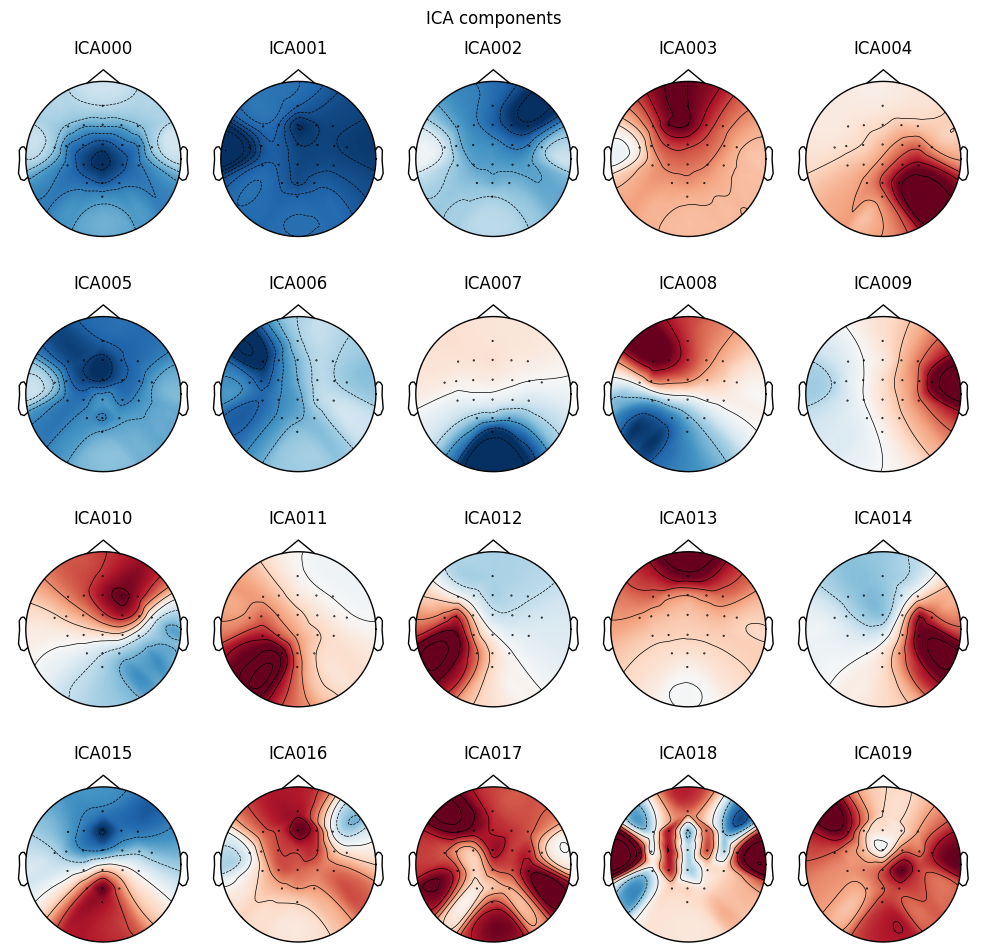

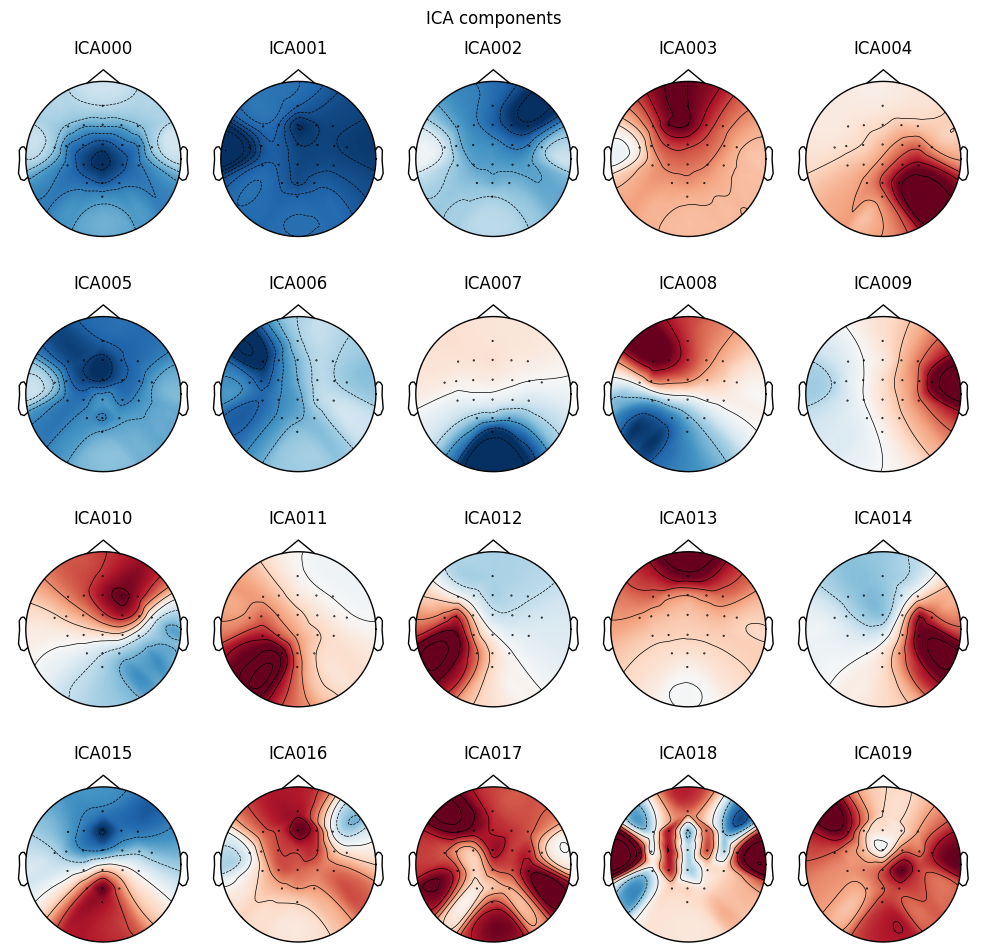

In [9]:
# Cell 6: Independent Component Analysis (ICA)
# This is where the "Science" happens. We decompose the signal to find artifacts.
ica = mne.preprocessing.ICA(n_components=20, random_state=97, max_iter=800)
ica.fit(raw_filtered)

# Plot the components. 
# Components that are localized near the eyes (front of the head) are usually blinks.
ica.plot_components()



Used Annotations descriptions: [np.str_('feet'), np.str_('left_hand'), np.str_('right_hand'), np.str_('tongue')]
Not setting metadata
48 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 48 events and 1051 original time points ...
0 bad epochs dropped


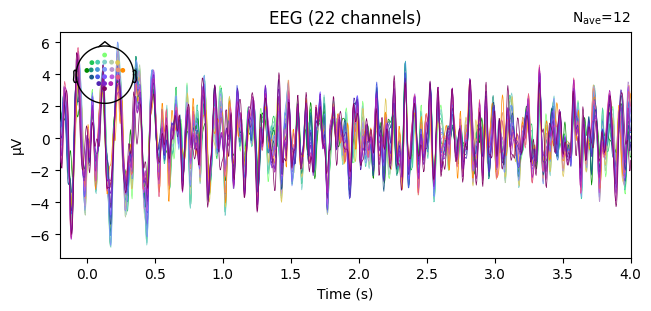

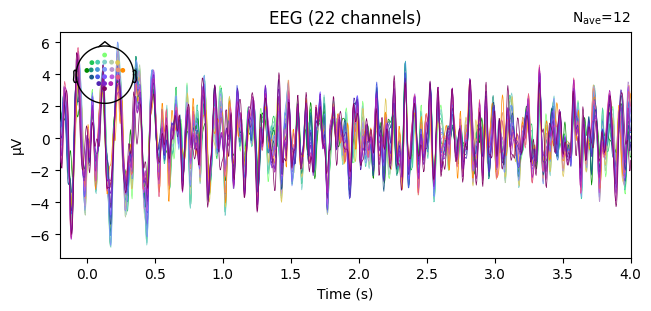

In [10]:
# Cell 7: Epoching (Segmenting for ML)
# We cut the data into chunks based on when the user was cued to imagine movement.
events, event_id = mne.events_from_annotations(raw_filtered)
# Standard event IDs for this dataset: 'left_hand', 'right_hand', 'feet', 'tongue'
epochs = mne.Epochs(raw_filtered, events, event_id, tmin=-0.2, tmax=4.0, baseline=(None, 0), preload=True)

# Visualize the average response for 'left_hand'
epochs['left_hand'].average().plot()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


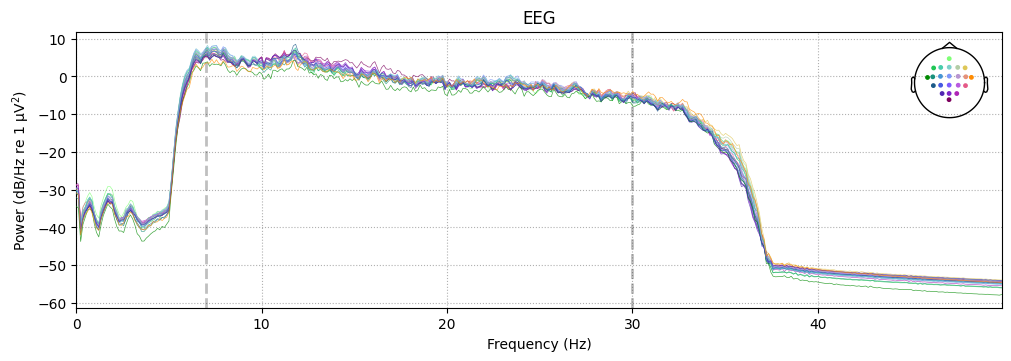

In [11]:
# Apply a bandpass filter
# 7Hz to 30Hz is the standard range for motor imagery
raw_filtered = raw.copy().filter(l_freq=7., h_freq=30., fir_design='firwin')

# Plot the PSD again to see how the 'noise' outside 7-30Hz is gone
raw_filtered.compute_psd(fmax=50).plot()


Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 1.6s.


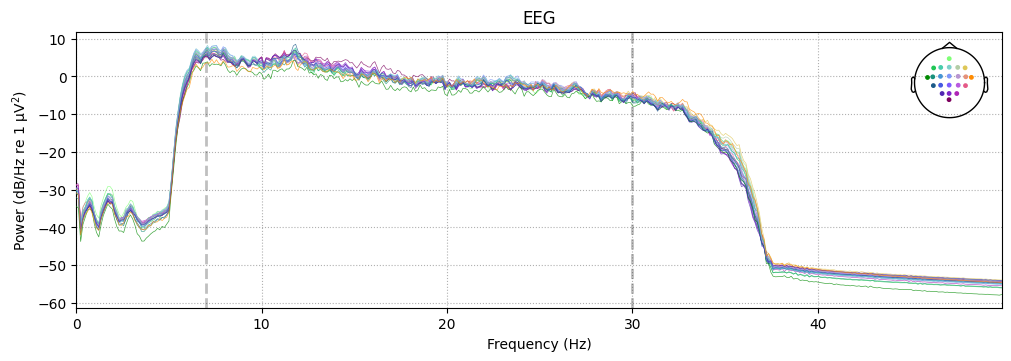

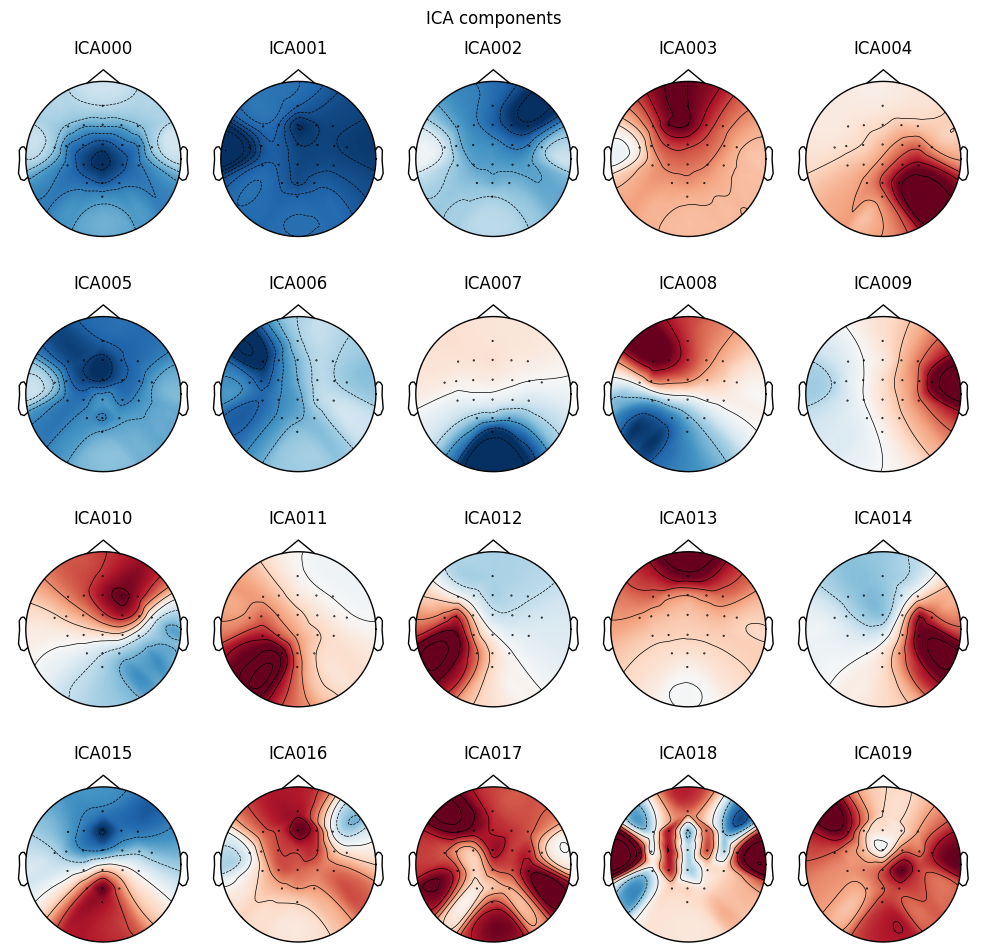

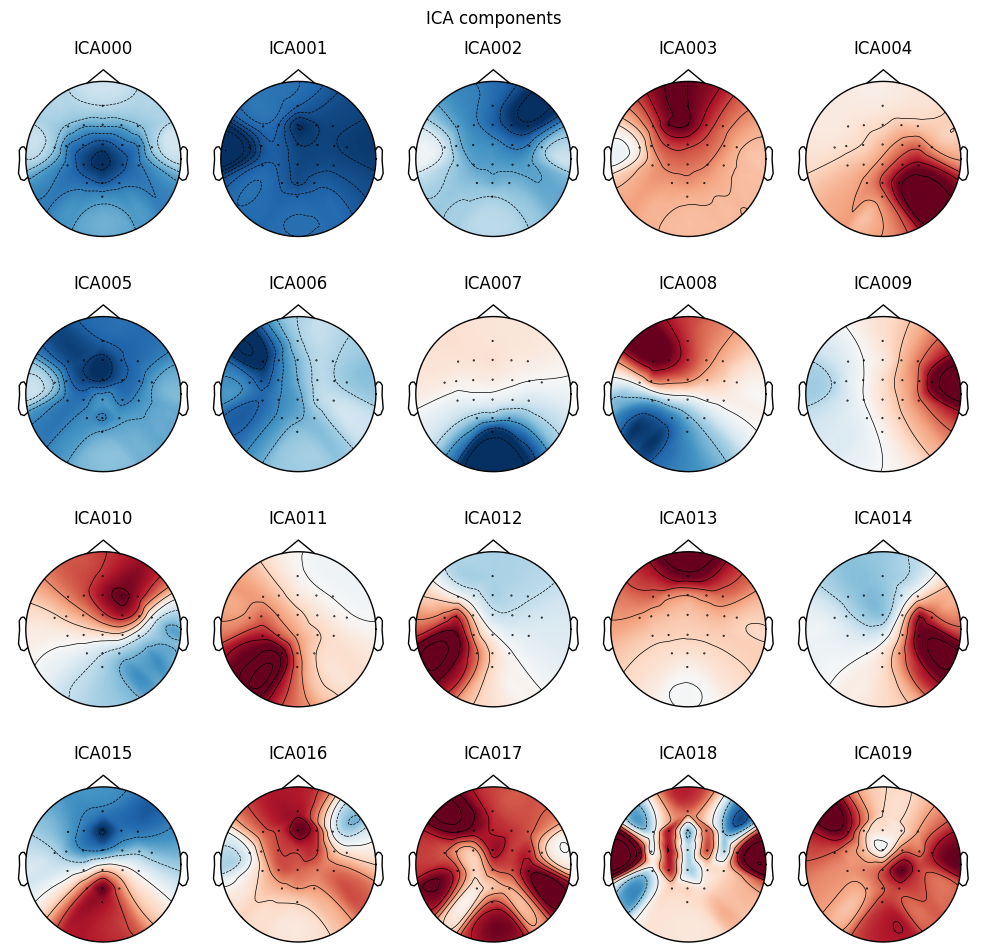

In [12]:
# 1. Initialize ICA
ica = mne.preprocessing.ICA(n_components=20, random_state=97, max_iter=800)

# 2. Fit ICA to the filtered data
ica.fit(raw_filtered)

# 3. Plot the components
# Look for a component that is concentrated at the very front of the head (the eyes)
ica.plot_components()


In [13]:
# Find the events in the data
events, event_id = mne.events_from_annotations(raw_filtered)

# Define the time window: -0.2s before the arrow to 4.0s after
tmin, tmax = -0.2, 4.0

# Create the epochs
epochs = mne.Epochs(raw_filtered, events, event_id, tmin, tmax, 
                    baseline=(None, 0), preload=True, reject=None)

# Let's see how many trials we have for each class
print(epochs)


Used Annotations descriptions: [np.str_('feet'), np.str_('left_hand'), np.str_('right_hand'), np.str_('tongue')]
Not setting metadata
48 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 48 events and 1051 original time points ...
0 bad epochs dropped
<Epochs | 48 events (all good), -0.2 – 4 s (baseline -0.2 – 0 s), ~10.0 MiB, data loaded,
 np.str_('feet'): 12
 np.str_('left_hand'): 12
 np.str_('right_hand'): 12
 np.str_('tongue'): 12>


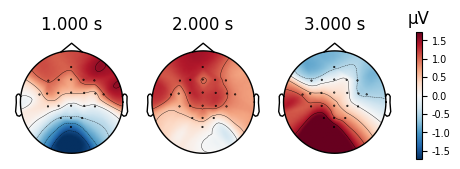

<Figure size 640x480 with 0 Axes>

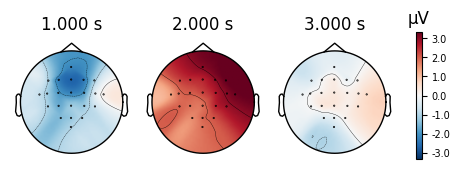

<Figure size 640x480 with 0 Axes>

In [15]:
# Plot the average brain activity (Evoked response) for Left vs Right hand
import matplotlib.pyplot as plt

# Get the keys dynamically to avoid naming errors
left_key = '769' if '769' in epochs.event_id else 'left_hand'
right_key = '770' if '770' in epochs.event_id else 'right_hand'

evoked_left = epochs[left_key].average()
evoked_right = epochs[right_key].average()

# Plot Left Hand Imagery
fig_left = evoked_left.plot_topomap(times=[1.0, 2.0, 3.0], ch_type='eeg')
plt.suptitle("Left Hand Imagery")
plt.show()

# Plot Right Hand Imagery
fig_right = evoked_right.plot_topomap(times=[1.0, 2.0, 3.0], ch_type='eeg')
plt.suptitle("Right Hand Imagery")
plt.show()

